# Phase 2 – Exploratory Data Analysis (EDA)

**Datasets covered**
- **UIKD** – *Institutional Knowledge Dataset* (scraped UNT data)
- **SSCD** – *Synthetic Student Context Dataset* (generated by vihal)

## Project overview
This notebook performs an end-to-end EDA for both datasets to support Phase 2. It includes:
- Dataset descriptions and schema overview  
- Data quality checks (missing values, duplicates, sanity checks)  
- Visual discovery (multiple plot types per dataset, each with labels + interpretation)  
- Descriptive statistics and correlation analysis  
- A final summary section: **Key Findings from EDA**


## Team Roles & Responsibilities

| Member | Role | Responsibilities |
|--------|------|------------------|
| **Yash Bhamore** | Project Lead & System Integration | Problem framing, dataset integration, final review |
| **Darsh Atulkumar Joshi** | EDA Lead | Exploratory analysis, visualization, insights |
| **Vihal Thatipamula** | Statistical Analysis Support | Descriptive statistics, correlations, anomaly detection |
| **Sai Bhargav Yaga** | Data Acquisition & Feature Engineering | Web scraping, data cleaning, feature preparation |

## 0. Setup

In [9]:
# Core
import pandas as pd
import numpy as np
import re
from collections import Counter

# Viz (matplotlib-only)
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# File paths (edit if you mount from Drive / Colab)
UIKD_PATH = "/content/uikd_items.csv"
SSCD_PATH = "/content/SSCD_1000_students_with_oncampus_work (1) (1).csv"


## 1. Load datasets

In [10]:
uikd = pd.read_csv(UIKD_PATH)
sscd = pd.read_csv(SSCD_PATH)

print("UIKD shape:", uikd.shape)
print("SSCD shape:", sscd.shape)

display(uikd.head(3))
display(sscd.head(3))


UIKD shape: (1058, 12)
SSCD shape: (1000, 20)


,doc_id,item_id,chunk_index,category,page_title,url,captured_at,item_title,item_text,deadline_signals,action_cues,tags
0,6ec93d8c4b6af38f61957fd05c24b15c,7c187f043c82dd9fa4c80acf6630ee9f,0,financial_aid,Financial Aid | University of North Texas,https://financialaid.unt.edu/index.html,2026-02-13T05:28:06.435124,Financial Aid | University of North Texas Fina...,Financial Aid | University of North Texas Fina...,Fall 2026; October 1 2026; deadline,apply; complete; submit; visit,"aid, financial, fafsa, tasfa, scholarships, 15..."
1,6ec93d8c4b6af38f61957fd05c24b15c,d184b75a801f8b3817aaa17eeadfe2e4,1,financial_aid,Financial Aid | University of North Texas,https://financialaid.unt.edu/index.html,2026-02-13T05:28:06.435124,$450 MILLION in scholarships and financial aid...,$450 MILLION in scholarships and financial aid...,Fall 2026; October 1 2026; deadline,apply; complete; submit; visit,"aid, financial, fafsa, tasfa, scholarships, 15..."
2,6ec93d8c4b6af38f61957fd05c24b15c,3db7d18ae58405eed9f0489417067624,2,financial_aid,Financial Aid | University of North Texas,https://financialaid.unt.edu/index.html,2026-02-13T05:28:06.435124,"April 15 Continue to monitor ""To Do List"" item...","April 15 Continue to monitor ""To Do List"" item...",Fall 2026; October 1 2026; deadline,apply; complete; submit; visit,"aid, financial, fafsa, tasfa, scholarships, 15..."


,student_id,student_level,international_status,program_category,semester_stage,semester,program_total_credits,credits,part_time_enrollment,scholarships,financial_aid,area_of_interest,research,academic_advisor,date_of_birth,age,SSN,nationality,place_of_birth,on_campus_work
0,SSCD_926,Undergraduate,Domestic,Data Science,Fall,5,120,12,NaN,"Athlete, In-State, General","Direct Unsubsidized Loan, Pell Grant","Financial Analytics, Big Data Analytics","Dr. Omar Hassan, Dr. Jacob Stein",Samantha Reed,2005-12-21,20,839-43-9201,American,Texas,Yes
1,SSCD_693,Undergraduate,Domestic,Data Science,Fall,2,120,9,NaN,General,NaN,"Predictive Modeling, Big Data Analytics","Dr. Aisha Rahman, Dr. Jacob Stein",Jordan Nguyen,2006-03-19,19,822-44-7807,American,California,Yes
2,SSCD_895,Undergraduate,Domestic,Engineering,Fall,6,120,9,NaN,"Merit, In-State, General","Work Study, In-State Grant","Biomedical Engineering, IoT Systems, Renewable...","Dr. Fatima Ali, Dr. Keira Johnson, Dr. Hannah ...",Taylor Johnson,2004-01-28,21,835-99-7291,American,Texas,Yes


## 2. Dataset descriptions

### 2.1 UIKD (Institutional Knowledge Dataset)
Represents scraped institutional knowledge items from UNT sources. Each row is an extracted chunk/item with metadata such as category, page title/URL, and extracted signals like deadline/action cues.

### 2.2 SSCD (Synthetic Student Context Dataset)
Represents synthetic student context records (1 row per student) including demographics and academic attributes (e.g., level, program, credits, semester stage).  
**Note:** This dataset contains sensitive-looking fields (e.g., `SSN`, `date_of_birth`). For EDA, we avoid printing raw values from such columns and focus on schema, missingness, and distribution-level summaries.


## 3. Data Quality Checks (both datasets)

In [11]:
def data_quality_report(df: pd.DataFrame, name: str):
    print("="*80)
    print(f"{name} — Data Quality Checks")
    print("="*80)

    # Shape
    print("Shape (rows, cols):", df.shape)

    # Column overview
    print("Column overview:")
    display(pd.DataFrame({
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "non_null_count": df.notna().sum().values,
        "null_count": df.isna().sum().values,
        "null_%": (df.isna().mean()*100).round(2).values
    }))

    # Missing values summary
    print("Top missing columns:")
    miss = df.isna().mean().sort_values(ascending=False)
    display((miss*100).round(2).head(15).to_frame("missing_%"))

    # Duplicate checks
    dup_rows = df.duplicated().sum()
    print(f"Duplicate rows (full-row exact duplicates): {dup_rows}")

    # Basic sanity checks (lightweight + generic)
    # numeric columns: report negatives (if any)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if num_cols:
        negs = {c: int((df[c] < 0).sum()) for c in num_cols}
        negs = {k:v for k,v in negs.items() if v>0}
        print("Numeric sanity checks:")
        if negs:
            print("Negative values found:", negs)
        else:
            print("No negative values found in numeric columns.")
    else:
        print("No numeric columns detected for numeric sanity checks.")

data_quality_report(uikd, "UIKD")
data_quality_report(sscd, "SSCD")


UIKD — Data Quality Checks
Shape (rows, cols): (1058, 12)
Column overview:


,column,dtype,non_null_count,null_count,null_%
0,doc_id,object,1058,0,0.00
1,item_id,object,1058,0,0.00
2,chunk_index,int64,1058,0,0.00
3,category,object,1058,0,0.00
4,page_title,object,1058,0,0.00
5,url,object,1058,0,0.00
6,captured_at,object,1058,0,0.00
7,item_title,object,1058,0,0.00
8,item_text,object,1058,0,0.00
9,deadline_signals,object,723,335,31.66


Top missing columns:


,missing_%
deadline_signals,31.66
action_cues,3.31
doc_id,0.00
item_id,0.00
category,0.00
chunk_index,0.00
page_title,0.00
url,0.00
item_title,0.00
captured_at,0.00


Duplicate rows (full-row exact duplicates): 0
Numeric sanity checks:
No negative values found in numeric columns.
SSCD — Data Quality Checks
Shape (rows, cols): (1000, 20)
Column overview:


,column,dtype,non_null_count,null_count,null_%
0,student_id,object,1000,0,0.0
1,student_level,object,1000,0,0.0
2,international_status,object,1000,0,0.0
3,program_category,object,1000,0,0.0
4,semester_stage,object,1000,0,0.0
5,semester,int64,1000,0,0.0
6,program_total_credits,int64,1000,0,0.0
7,credits,int64,1000,0,0.0
8,part_time_enrollment,object,411,589,58.9
9,scholarships,object,1000,0,0.0


Top missing columns:


,missing_%
part_time_enrollment,58.9
SSN,41.9
financial_aid,29.2
research,11.6
program_category,0.0
international_status,0.0
student_level,0.0
student_id,0.0
credits,0.0
program_total_credits,0.0


Duplicate rows (full-row exact duplicates): 0
Numeric sanity checks:
No negative values found in numeric columns.


## 4. UIKD — Visual Discovery

In [12]:
# Helper features for UIKD
uikd_vis = uikd.copy()

# Text length (characters and approximate tokens via whitespace split)
uikd_vis["text_len_chars"] = uikd_vis["item_text"].astype(str).str.len()
uikd_vis["text_len_words"] = uikd_vis["item_text"].astype(str).str.split().str.len()

def split_semicolon_list(x):
    if pd.isna(x):
        return []
    return [t.strip() for t in str(x).split(";") if t.strip()]

# Action cues & deadline signals as lists
uikd_vis["action_cues_list"] = uikd_vis["action_cues"].apply(split_semicolon_list)
uikd_vis["deadline_signals_list"] = uikd_vis["deadline_signals"].apply(split_semicolon_list)

# Flatten for frequency charts
action_counts = Counter([t.lower() for sub in uikd_vis["action_cues_list"] for t in sub])
deadline_counts = Counter([t.lower() for sub in uikd_vis["deadline_signals_list"] for t in sub])


### 4.1 Category distribution (UIKD)

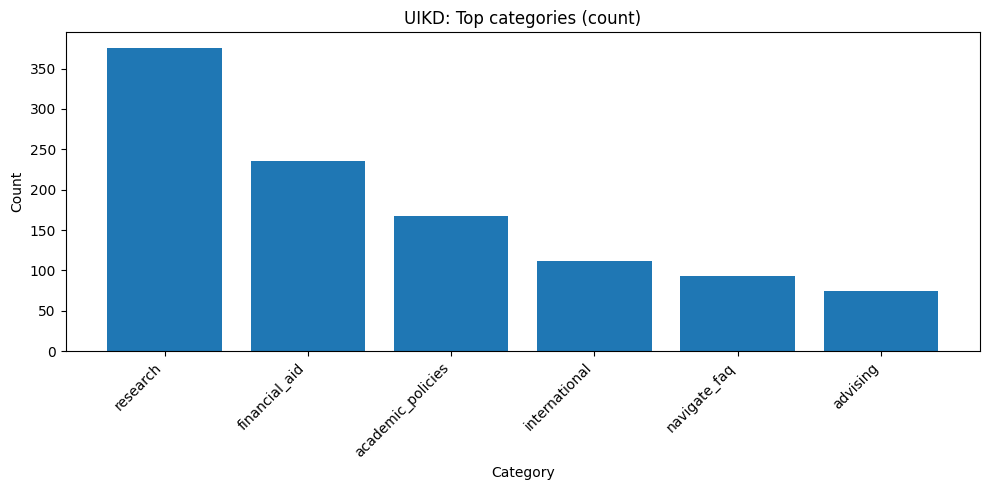

Top categories:


,count
category,
research,376
financial_aid,235
academic_policies,168
international,112
navigate_faq,93
advising,74


In [13]:
cat_counts = uikd_vis["category"].fillna("UNKNOWN").value_counts().head(25)

plt.figure(figsize=(10, 5))
plt.bar(cat_counts.index.astype(str), cat_counts.values)
plt.title("UIKD: Top categories (count)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Top categories:")
display(cat_counts.to_frame("count"))


**Interpretation:**

The UIKD dataset is heavily dominated by the research category, followed by financial aid and academic policies, while categories such as international, navigate_faq, and advising have noticeably fewer entries. This indicates a clear class imbalance where a few categories make up the majority of the data, which could bias models toward these dominant categories and reduce performance on less-represented ones, suggesting a need for balancing or grouping smaller categories.

### 4.2 Chunk/text length distribution (UIKD)

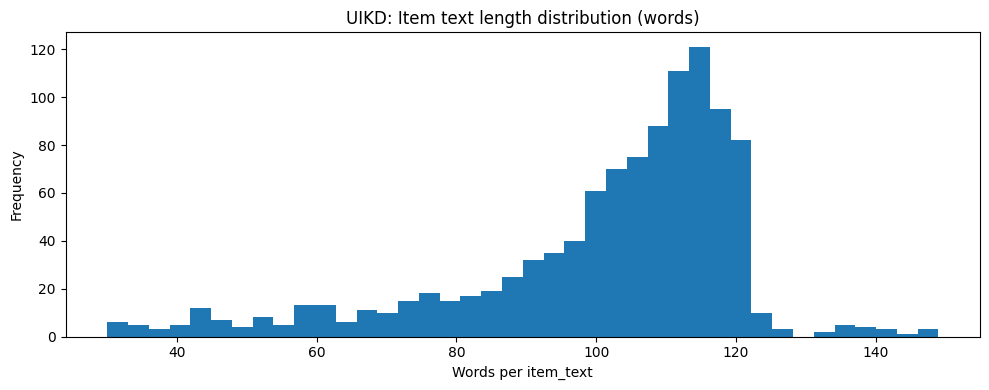

Text length (words) summary:


,count,mean,std,min,25%,50%,75%,max
text_len_words,1058.0,101.192817,20.590127,30.0,94.0,107.0,115.0,149.0


In [14]:
plt.figure(figsize=(10, 4))
plt.hist(uikd_vis["text_len_words"].replace([np.inf, -np.inf], np.nan).dropna(), bins=40)
plt.title("UIKD: Item text length distribution (words)")
plt.xlabel("Words per item_text")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Text length (words) summary:")
display(uikd_vis["text_len_words"].describe().to_frame().T)


**Interpretation:**

The text length distribution shows that most UIKD entries fall within the 90–120 word range, indicating that the dataset primarily consists of moderately long, context-rich chunks rather than short snippets. While this is beneficial for preserving meaning, the presence of some shorter and longer outliers suggests variability in chunking, which could impact embedding consistency and retrieval performance, making it useful to standardize or trim extreme lengths.


### 4.3 Deadline / action cue frequency (UIKD)

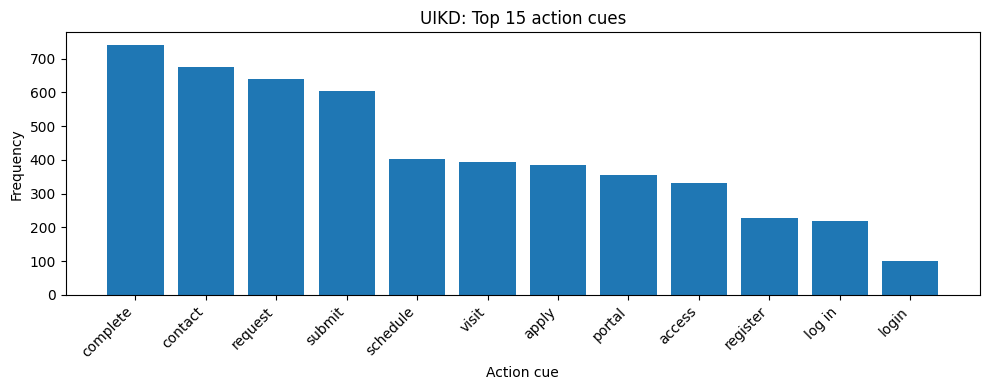

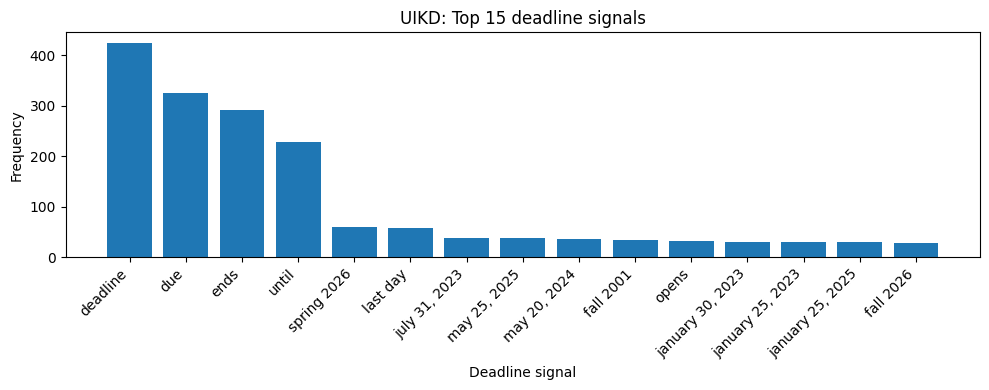

,action_cue_count
complete,741
contact,676
request,641
submit,605
schedule,404
visit,394
apply,384
portal,354
access,333
register,229


,deadline_signal_count
deadline,424
due,326
ends,292
until,228
spring 2026,60
last day,58
"july 31, 2023",38
"may 25, 2025",38
"may 20, 2024",35
fall 2001,34


In [15]:
top_n = 15

# Action cues
ac = pd.Series(dict(action_counts)).sort_values(ascending=False).head(top_n)
plt.figure(figsize=(10, 4))
plt.bar(ac.index, ac.values)
plt.title(f"UIKD: Top {top_n} action cues")
plt.xlabel("Action cue")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Deadline signals (may be phrase-like)
dc = pd.Series(dict(deadline_counts)).sort_values(ascending=False).head(top_n)
plt.figure(figsize=(10, 4))
plt.bar(dc.index, dc.values)
plt.title(f"UIKD: Top {top_n} deadline signals")
plt.xlabel("Deadline signal")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(ac.to_frame("action_cue_count"))
display(dc.to_frame("deadline_signal_count"))


**Interpretation:**
- The action-cue distribution is strongly concentrated in a small set of common task verbs—“complete,” “contact,” “request,” and “submit” dominate by a large margin—showing that much of UIKD content is instructional and oriented around student/admin workflows (forms, requests, submissions, scheduling, portal access). The long tail drops off quickly after the top few cues, which suggests the dataset repeatedly emphasizes similar actions; also, the presence of both “log in” and “login” indicates minor text normalization issues (synonyms/formatting variants) that could be cleaned to improve consistency for downstream modeling and retrieval.
- Deadline signals are led by generic time-pressure terms like “deadline,” “due,” “ends,” and “until,” implying many entries refer to time-sensitive requirements but often in broad language rather than precise dates. After these top terms, the frequencies fall sharply and include a mix of specific date phrases (e.g., “July 31, 2023,” “May 25, 2025”) and term-based markers (e.g., “Spring 2026,” “Fall 2026”), suggesting deadline information appears in multiple formats; this variability can complicate automated extraction, so standardizing date/term expressions (or adding parsing rules) would likely improve reliability for deadline-aware features.

## 5. UIKD — Descriptive Statistics

In [26]:
# Numeric fields (if any)
num_cols_uikd = uikd.select_dtypes(include=[np.number]).columns.tolist()
if num_cols_uikd:
    display(uikd[num_cols_uikd].describe().T)

# UIKD text length descriptive stats
print(uikd_vis[['text_len_chars', 'text_len_words']].agg(['mean', 'median', 'std']))

# Categorical value counts (top)
cat_cols_uikd = [c for c in uikd.columns if uikd[c].dtype == "object"]
for c in ["category", "page_title"]:
    if c in uikd.columns:
        vc = uikd[c].fillna("UNKNOWN").value_counts().head(15)
        print(f"UIKD value counts: {c}")
        display(pd.DataFrame({"value": vc.index.astype(str), "count": vc.values, "pct": (vc.values/len(uikd)*100).round(2)}))


,count,mean,std,min,25%,50%,75%,max
chunk_index,1058.0,5.699433,7.616048,0.0,1.0,3.0,7.0,45.0


        text_len_chars  text_len_words
mean        663.680529      101.192817
median      681.000000      107.000000
std         152.368963       20.590127
UIKD value counts: category


,value,count,pct
0,research,376,35.54
1,financial_aid,235,22.21
2,academic_policies,168,15.88
3,international,112,10.59
4,navigate_faq,93,8.79
5,advising,74,6.99


UIKD value counts: page_title


,value,count,pct
0,Frequently Asked Questions | University of No...,50,4.73
1,Guidance for Sponsored Expenditures | Univers...,46,4.35
2,Residency Information | University of North T...,34,3.21
3,Student Research Guidance | University of Nor...,29,2.74
4,Application Guides & Resources | University o...,29,2.74
5,Frequently Asked Questions - University Librar...,27,2.55
6,Student Research Development | University of ...,25,2.36
7,IRB Protocol Submission | University of North...,21,1.98
8,Partnering with Programs at UNT | University ...,19,1.80
9,Research and Creativity Awards | University o...,17,1.61


## 6. SSCD — Visual Discovery

In [17]:
sscd_vis = sscd.copy()

# Identify sensitive columns we should NOT print raw
SENSITIVE_COLS = {"SSN", "date_of_birth"}
safe_preview_cols = [c for c in sscd_vis.columns if c not in SENSITIVE_COLS]

print("Safe columns (excluding sensitive-looking):", safe_preview_cols)


Safe columns (excluding sensitive-looking): ['student_id', 'student_level', 'international_status', 'program_category', 'semester_stage', 'semester', 'program_total_credits', 'credits', 'part_time_enrollment', 'scholarships', 'financial_aid', 'area_of_interest', 'research', 'academic_advisor', 'age', 'nationality', 'place_of_birth', 'on_campus_work']


### 6.1 Distribution of student 'goals' (proxy via area_of_interest)

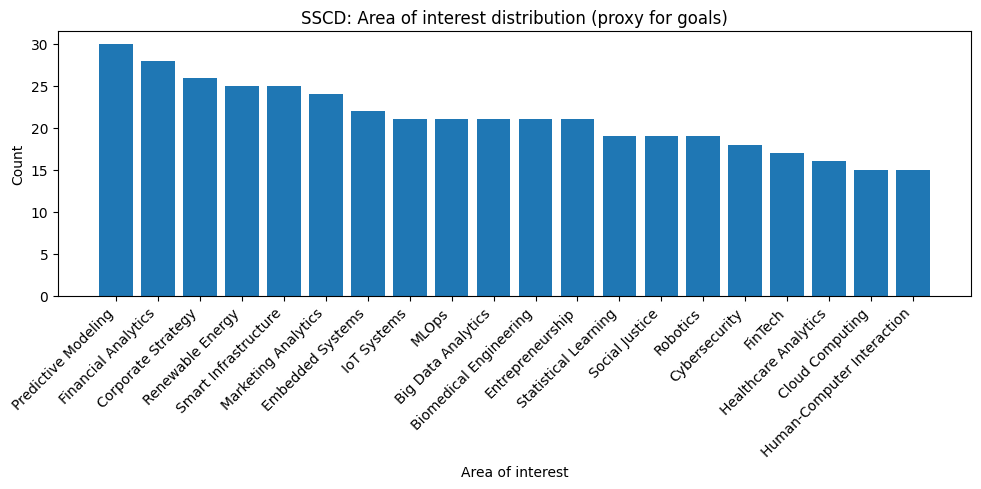

,value,count,pct
0,Predictive Modeling,30,3.0
1,Financial Analytics,28,2.8
2,Corporate Strategy,26,2.6
3,Renewable Energy,25,2.5
4,Smart Infrastructure,25,2.5
5,Marketing Analytics,24,2.4
6,Embedded Systems,22,2.2
7,IoT Systems,21,2.1
8,MLOps,21,2.1
9,Big Data Analytics,21,2.1


In [18]:
col = "area_of_interest" if "area_of_interest" in sscd_vis.columns else None
if col:
    vc = sscd_vis[col].fillna("UNKNOWN").value_counts().head(20)
    plt.figure(figsize=(10, 5))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title("SSCD: Area of interest distribution (proxy for goals)")
    plt.xlabel("Area of interest")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame({"value": vc.index.astype(str), "count": vc.values, "pct": (vc.values/len(sscd_vis)*100).round(2)}))
else:
    print("No 'area_of_interest' column found. Replace this section with the closest goals-like column.")


**Interpretation:**
- The distribution of areas of interest is relatively well-balanced, with no single category overwhelmingly dominating the dataset; the highest category (Predictive Modeling) only accounts for about 3%, and most others fall within a narrow range of roughly 1.5%–2.8%. This suggests that the dataset was intentionally generated to provide diverse and evenly distributed student goals, reducing the risk of bias toward any particular field. However, there is still a slight skew toward data/analytics-related areas (e.g., predictive modeling, financial analytics, big data), which could subtly influence downstream models to favor these domains, so ensuring continued balance or weighting may help maintain fairness in goal-based predictions.


### 6.2 Distribution of level / program / international status / on-campus work

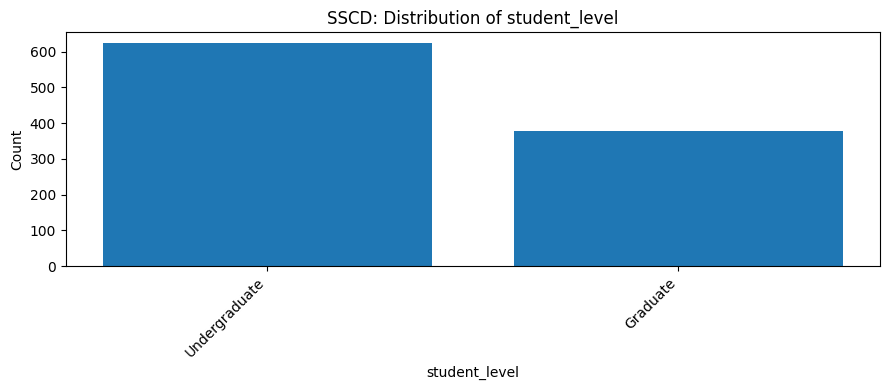

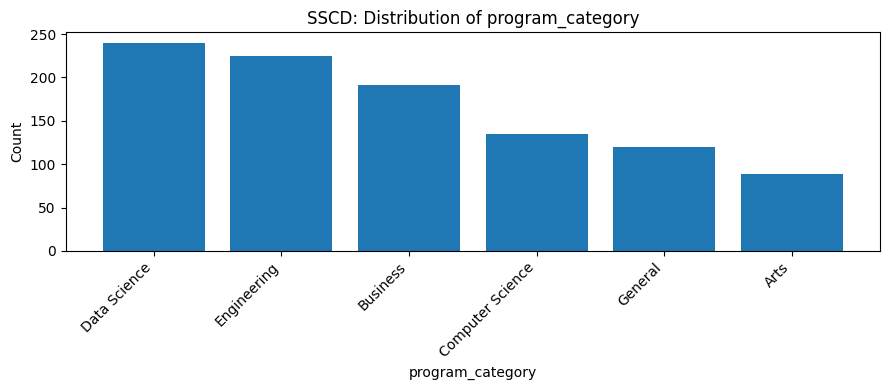

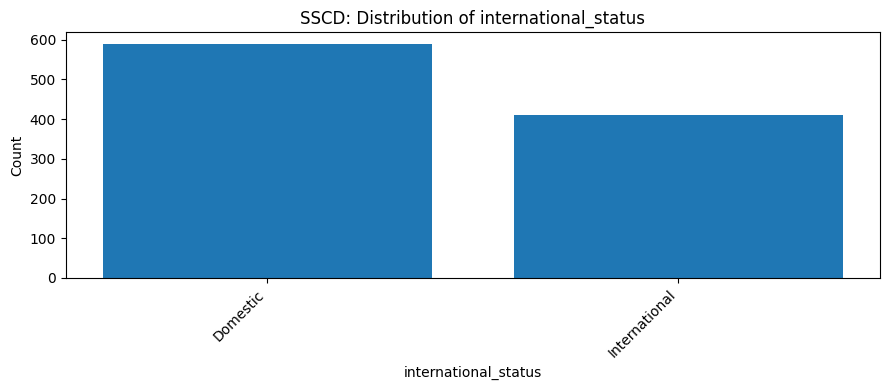

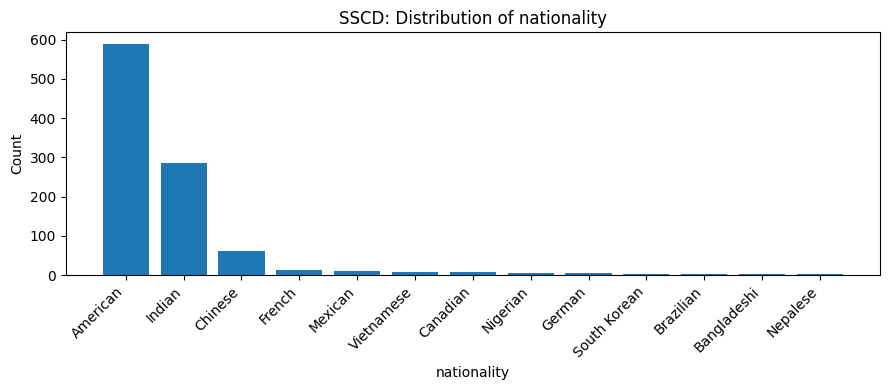

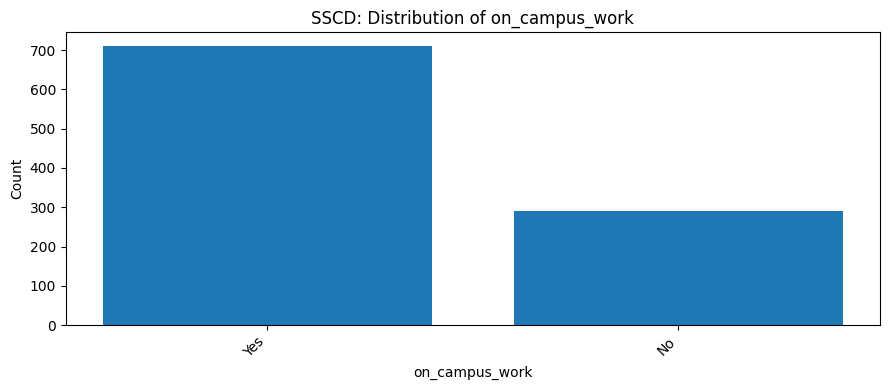

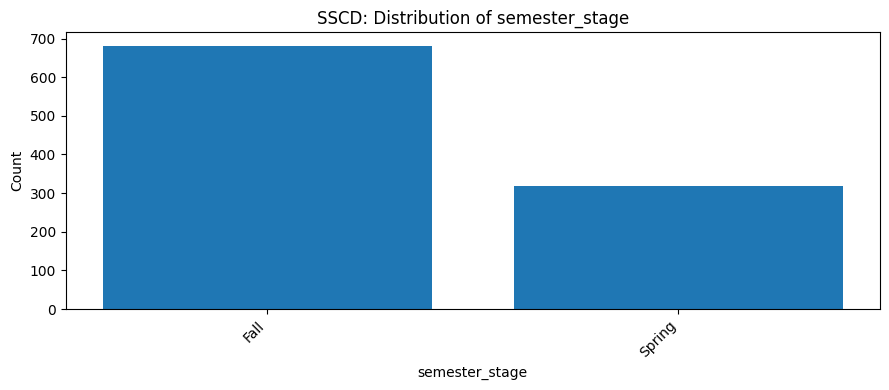

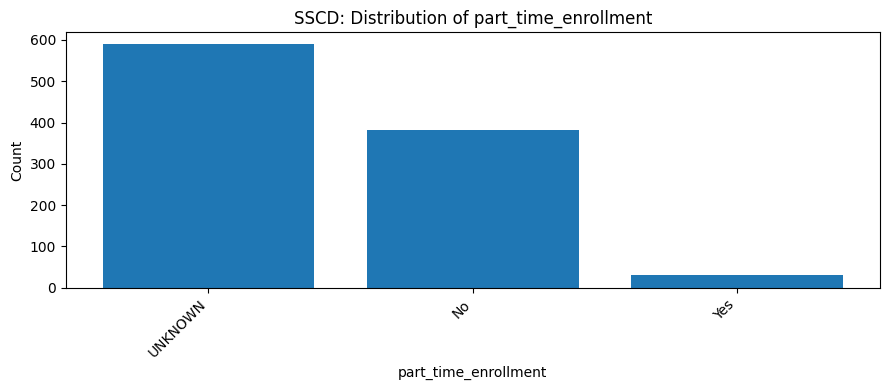

In [19]:
cat_fields = [c for c in ["student_level","program_category","international_status","nationality","on_campus_work","semester_stage","part_time_enrollment"] if c in sscd_vis.columns]
for c in cat_fields:
    vc = sscd_vis[c].fillna("UNKNOWN").value_counts().head(20)
    plt.figure(figsize=(9, 4))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f"SSCD: Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


**Interpretation:**
- The SSCD dataset shows some noticeable imbalances across categories: undergraduate students, domestic students, and fall semester enrollments dominate, while graduate, international, and spring students are less represented. Program categories are somewhat varied but still slightly skewed toward data science, engineering, and business, and nationality is heavily concentrated in a few groups (especially American and Indian), with many other nationalities being rare. Additionally, most students have on-campus jobs, and part-time enrollment is largely marked as “UNKNOWN,” indicating possible data gaps. These imbalances suggest that certain student profiles are overrepresented, so downstream models may perform better for these groups while underperforming on less-represented categories, highlighting the need to account for coverage gaps during evaluation.

### 6.3 Numeric feature distributions (SSCD)

Numeric columns: ['semester', 'program_total_credits', 'credits', 'age']


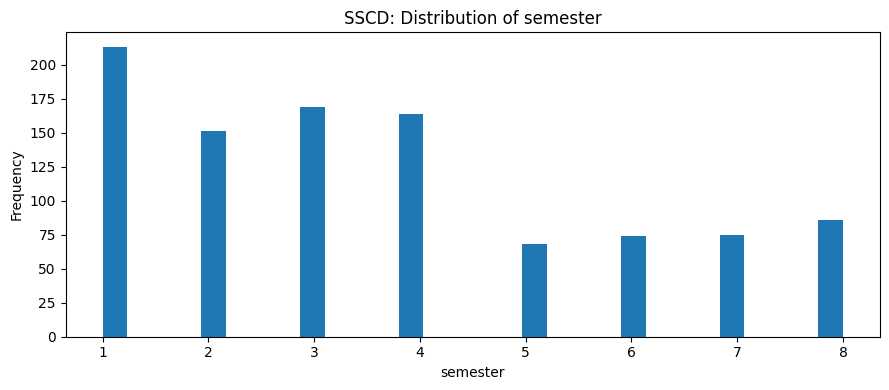

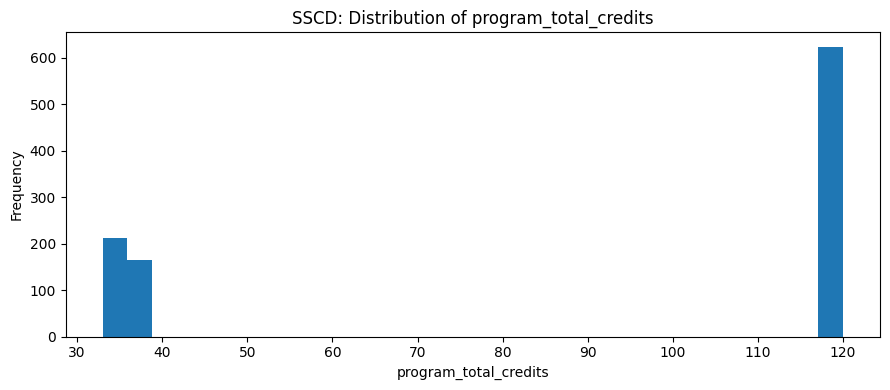

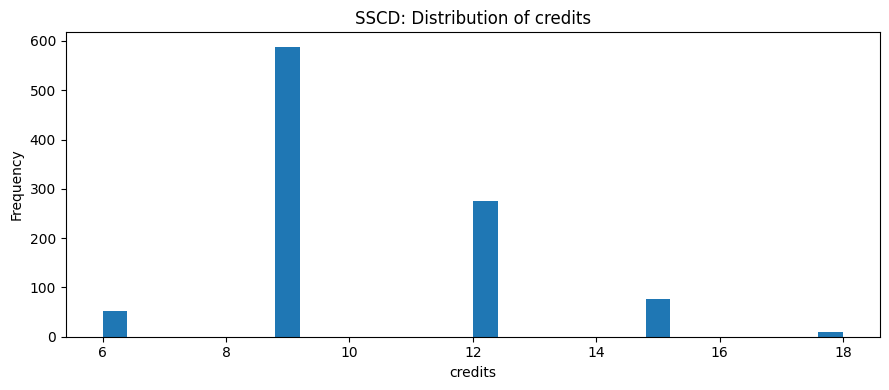

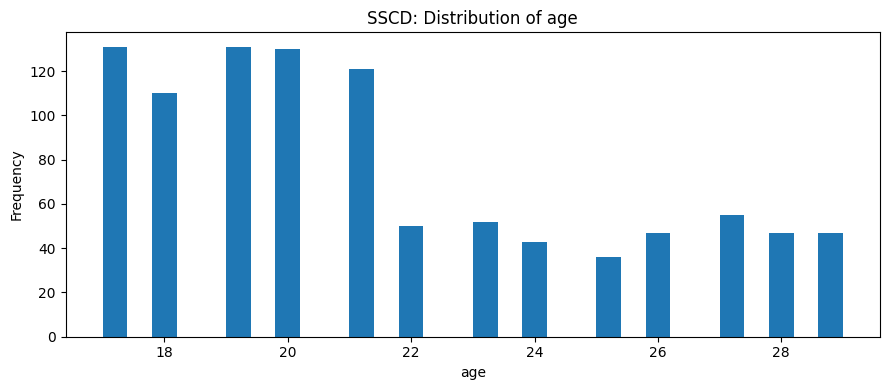

,count,mean,std,min,25%,50%,75%,max
semester,1000.0,3.675,2.237047,1.0,2.0,3.0,5.0,8.0
program_total_credits,1000.0,87.693,41.561594,33.0,36.0,120.0,120.0,120.0
credits,1000.0,10.206,2.226774,6.0,9.0,9.0,12.0,18.0
age,1000.0,21.451,3.638246,17.0,19.0,20.0,24.0,29.0


In [20]:
num_cols = sscd_vis.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)

for c in num_cols:
    plt.figure(figsize=(9, 4))
    plt.hist(sscd_vis[c].dropna(), bins=30)
    plt.title(f"SSCD: Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

display(sscd_vis[num_cols].describe().T)


**Interpretation:**
- The numeric features appear to be within reasonable and realistic ranges, with semesters ranging from 1 to 8, credits typically between 6 and 18, and ages mostly between 17 and 29, which aligns well with typical university student profiles. However, there are clear signs of multi-modal distributions, particularly in program_total_credits (clustered around ~30–40 and 120) and credits (peaks around 9 and 12), suggesting the presence of different subgroups such as part-time vs full-time students or undergraduate vs graduate programs. Similarly, the age distribution shows concentration around early 20s with some spread into older ages, indicating a mix of traditional and non-traditional students; these patterns highlight that the dataset captures multiple student populations, which is useful but should be considered when modeling.


### 6.4 Scatter plot between meaningful numeric features

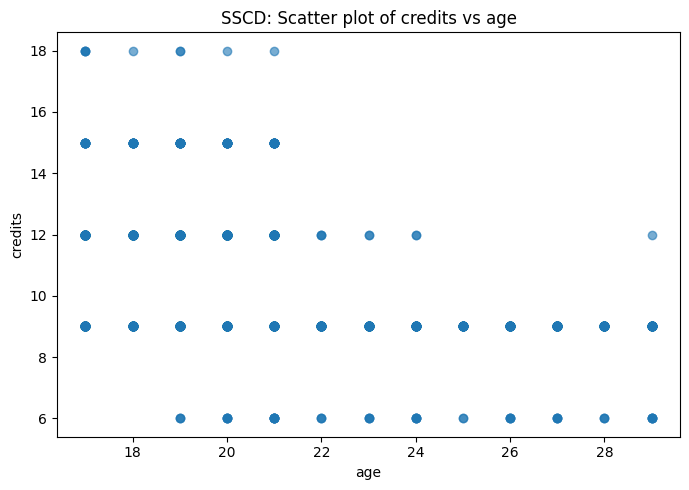

Pearson correlation(age, credits) = -0.446


In [21]:
# Choose a reasonable pair if present
x, y = None, None
candidates = sscd_vis.select_dtypes(include=[np.number]).columns.tolist()

if "age" in candidates and "credits" in candidates:
    x, y = "age", "credits"
elif len(candidates) >= 2:
    x, y = candidates[0], candidates[1]

if x and y:
    plt.figure(figsize=(7, 5))
    plt.scatter(sscd_vis[x], sscd_vis[y], alpha=0.6)
    plt.title(f"SSCD: Scatter plot of {y} vs {x}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

    corr_xy = sscd_vis[[x,y]].corr().iloc[0,1]
    print(f"Pearson correlation({x}, {y}) = {corr_xy:.3f}")
else:
    print("Not enough numeric columns found for a scatter plot.")


**Interpretation:**
- The scatter plot shows a moderate negative relationship between age and credits, supported by a Pearson correlation of approximately -0.45, indicating that as age increases, the number of credits tends to slightly decrease. Younger students (around 17–21) are more likely to take higher credit loads (e.g., 12–18), while older students tend to cluster around lower credit values (e.g., 6–9), suggesting possible differences between full-time and part-time enrollment patterns. Although the relationship is not perfectly linear, there is a clear trend showing that older students generally enroll in fewer credits.

### 6.5 Box Plot between meaningful numeric features

<Figure size 1000x500 with 0 Axes>

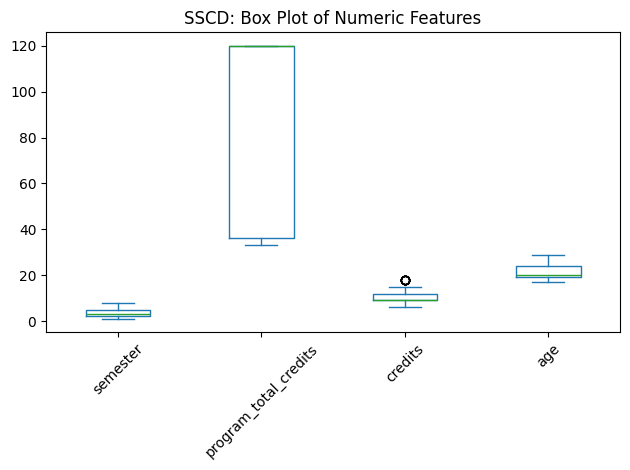

In [25]:
# Box Plot – SSCD Numeric Features
import matplotlib.pyplot as plt

# Select numeric columns
num_cols = sscd_vis.select_dtypes(include='number').columns

# Create box plot
plt.figure(figsize=(10, 5))
ax = sscd_vis[num_cols].plot(kind='box')
plt.title("SSCD: Box Plot of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:**
- The box plot reveals the distribution and variability of numeric student features. Most variables demonstrate moderate spread with limited extreme deviations, indicating realistic variability within the synthetic dataset. Notably, program_total_credits exhibits a wider range and visible upper-end outliers, suggesting diversity in academic progression among students. These variations are important for testing system robustness across different academic states.

### 6.6 Correlation heatmap (numeric features)

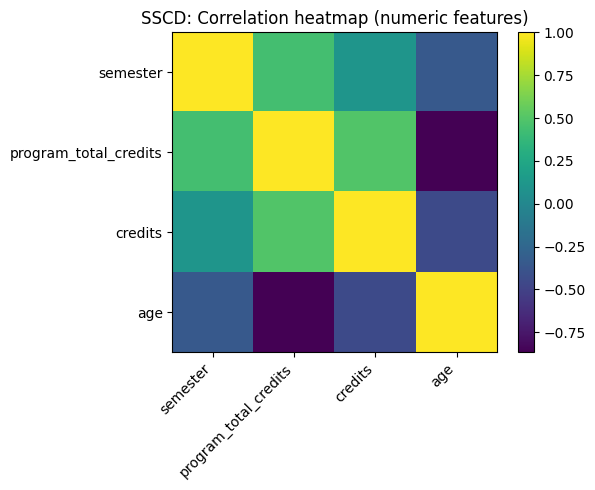

,semester,program_total_credits,credits,age
semester,1.000000,0.442466,0.109507,-0.346021
program_total_credits,0.442466,1.000000,0.494228,-0.866778
credits,0.109507,0.494228,1.000000,-0.445657
age,-0.346021,-0.866778,-0.445657,1.000000


In [23]:
num_cols = sscd_vis.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) >= 2:
    corr = sscd_vis[num_cols].corr()

    plt.figure(figsize=(6, 5))
    plt.imshow(corr.values, aspect="auto")
    plt.title("SSCD: Correlation heatmap (numeric features)")
    plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
    plt.yticks(range(len(num_cols)), num_cols)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    display(corr)
else:
    print("Not enough numeric columns for correlation heatmap.")


**Interpretation:**
- The correlation heatmap shows a strong negative correlation between age and program_total_credits (-0.87), indicating that older students tend to be in programs with fewer total credits, which may reflect different program types or could be an artifact of how the synthetic data was generated. There is also a moderate positive correlation between program_total_credits and credits (0.49), suggesting that students in larger programs tend to take more credits per semester, and a moderate negative correlation between age and credits (-0.45), meaning older students generally take fewer credits. Other relationships, such as semester with credits (0.11), are weak. Overall, while some correlations are realistic (e.g., credit load patterns), the very strong negative relationship with age may be artificially introduced during data generation and should be interpreted with caution.

## 7. SSCD — Descriptive Statistics

In [24]:
# Numeric stats: mean/median/std
num_cols = sscd.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    stats = pd.DataFrame({
        "mean": sscd[num_cols].mean(),
        "median": sscd[num_cols].median(),
        "std": sscd[num_cols].std()
    }).round(3)
    print("Numeric descriptive statistics (mean/median/std):")
    display(stats)

# Categorical value counts with percentages
cat_cols = [c for c in sscd.columns if sscd[c].dtype == "object" and c not in {"SSN", "date_of_birth"}]
for c in ["student_level","program_category","international_status","semester_stage","part_time_enrollment","scholarships","financial_aid","area_of_interest","nationality","on_campus_work"]:
    if c in cat_cols:
        vc = sscd[c].fillna("UNKNOWN").value_counts()
        out = pd.DataFrame({
            "value": vc.index.astype(str),
            "count": vc.values,
            "pct": (vc.values/len(sscd)*100).round(2)
        }).head(20)
        print(f"SSCD value counts: {c}")
        display(out)


Numeric descriptive statistics (mean/median/std):


,mean,median,std
semester,3.675,3.0,2.237
program_total_credits,87.693,120.0,41.562
credits,10.206,9.0,2.227
age,21.451,20.0,3.638


SSCD value counts: student_level


,value,count,pct
0,Undergraduate,623,62.3
1,Graduate,377,37.7


SSCD value counts: program_category


...

,value,count,pct
0,Predictive Modeling,30,3.0
1,Financial Analytics,28,2.8
2,Corporate Strategy,26,2.6
3,Renewable Energy,25,2.5
4,Smart Infrastructure,25,2.5
5,Marketing Analytics,24,2.4
6,Embedded Systems,22,2.2
7,IoT Systems,21,2.1
8,MLOps,21,2.1
9,Big Data Analytics,21,2.1


SSCD value counts: nationality


,value,count,pct
0,American,589,58.9
1,Indian,287,28.7
2,Chinese,61,6.1
3,French,14,1.4
4,Mexican,11,1.1
5,Vietnamese,7,0.7
6,Canadian,7,0.7
7,Nigerian,6,0.6
8,German,5,0.5
9,South Korean,4,0.4


SSCD value counts: on_campus_work


,value,count,pct
0,Yes,710,71.0
1,No,290,29.0


## 8. Key Findings from EDA



**Summary:**
- **UIKD coverage & imbalance:**  
  - The UIKD dataset is clearly dominated by the research category, followed by financial aid and academic policies, while categories like international, navigate_faq, and advising form a long tail with significantly fewer samples. This imbalance suggests that models trained on this data may favor dominant categories and underperform on less-represented ones, highlighting the need for balancing or weighting strategies.  
- **UIKD text quality:**  
  - The text chunks are generally moderate in length (around 90–120 words), indicating well-structured, context-rich segments suitable for retrieval tasks. However, there are some shorter and longer outliers, which could impact embedding consistency and retrieval efficiency, suggesting a need for more standardized chunk sizes.
- **UIKD deadline/action cues:**  
  - The most frequent action cues include complete, contact, request, and submit, showing that the dataset is heavily task-oriented and instructional. Deadline signals are present but somewhat inconsistent and varied in format, with common terms like “deadline” and “due” alongside specific dates, indicating that while deadlines are not sparse, they may require normalization for better extraction and modeling.  

- **SSCD coverage & imbalance:**  
  - The SSCD dataset shows imbalances with undergraduate, domestic, and fall semester students being the majority, along with a higher proportion of students in data science and engineering programs and those with on-campus jobs. Meanwhile, groups such as part-time students, certain nationalities, and less common programs are underrepresented, which may lead to biased model behavior.  
- **SSCD numeric sanity:**  
  - The numeric features fall within realistic ranges (e.g., age ~17–29, credits ~6–18, semester ~1–8), indicating good data validity. However, program_total_credits is skewed toward higher values (median = 120), which may reflect synthetic generation patterns and could introduce bias if not handled carefully.
- **SSCD relationships:**  
  - There is a moderate negative relationship between age and credits, suggesting older students tend to take fewer credits, and a strong negative correlation between age and program_total_credits, which may be partially artificial. Additionally, moderate correlations between credits and program size indicate meaningful structure, but some relationships may reflect synthetic design rather than real-world behavior.  

**Actionable recommendations:**
- To improve model performance, it is recommended to rebalance UIKD categories or apply weighting to handle class imbalance, and standardize text chunk lengths to improve embedding quality. Deadline signals should be normalized or enhanced using regex or augmentation techniques to improve consistency. For SSCD, ensure models are evaluated across underrepresented groups (e.g., international students, rare programs, part-time students) and consider addressing skewed features like program credits to reduce bias.
